<a href="https://colab.research.google.com/github/iisratislam/Generative_Modeling_Case-Study/blob/main/part2_octmnist_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Case Study — Part 2.1: OCT Retinal Images with a DCGAN

We train a **Deep Convolutional GAN (DCGAN)** to generate synthetic retinal
OCT (optical coherence tomography) images, using the **OCTMNIST** subset of
MedMNIST (28×28 grayscale images).

Steps:
1. Load and explore OCTMNIST (class distribution, sample images).
2. Build a DCGAN (convolutional generator + convolutional discriminator).
3. Train it, tracking generator and discriminator losses.
4. Generate synthetic retinal images.
5. Compare real vs. fake visually and quantitatively (Fréchet Inception Distance).
6. Reflect on quality and limitations.

Reference: Radford et al. (2016), "Unsupervised Representation Learning with
Deep Convolutional Generative Adversarial Networks" (DCGAN).

In [1]:
# Install the MedMNIST package (provides OCTMNIST with automatic download)
!pip install medmnist -q

%matplotlib inline
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

import medmnist
from medmnist import OCTMNIST, INFO

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("MedMNIST version:", medmnist.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.1 MB/s eta 0:00:00
Using device: cuda
MedMNIST version: 3.0.2


## 1. Load and explore OCTMNIST

OCTMNIST contains 28×28 grayscale retinal OCT images across 4 classes. We load
the training split, inspect the class distribution, and visualise a sample of
images to understand what the GAN needs to reproduce.

100%|██████████| 54.9M/54.9M [00:04<00:00, 13.2MB/s]


Number of training images: 97477
Image shape: (28, 28)
Pixel value range: 0 to 255

Classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}


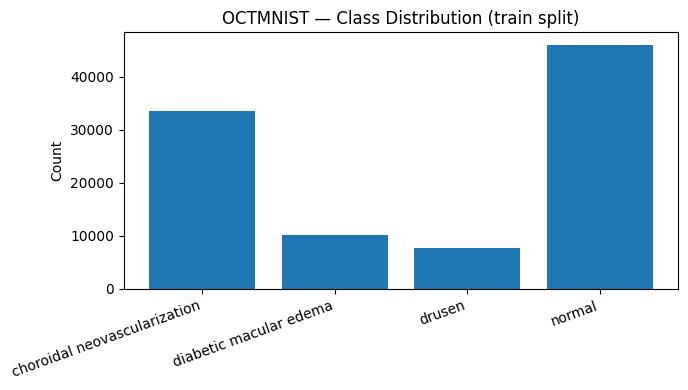

In [2]:
# Load the OCTMNIST training split (downloads automatically on first run)
train_dataset = OCTMNIST(split="train", download=True)

# Extract images and labels as numpy arrays
images = train_dataset.imgs          # shape: (N, 28, 28), values 0-255
labels = train_dataset.labels.flatten()  # shape: (N,)

print("Number of training images:", images.shape[0])
print("Image shape:", images.shape[1:])
print("Pixel value range:", images.min(), "to", images.max())

# Class distribution
class_names = INFO["octmnist"]["label"]
print("\nClasses:", class_names)

unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([class_names[str(u)] for u in unique], counts)
plt.title("OCTMNIST — Class Distribution (train split)")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 2. Visualise sample images

Before building the GAN, we look at a grid of real OCT images to understand
their visual characteristics — the layered retinal structures the generator
will need to reproduce.

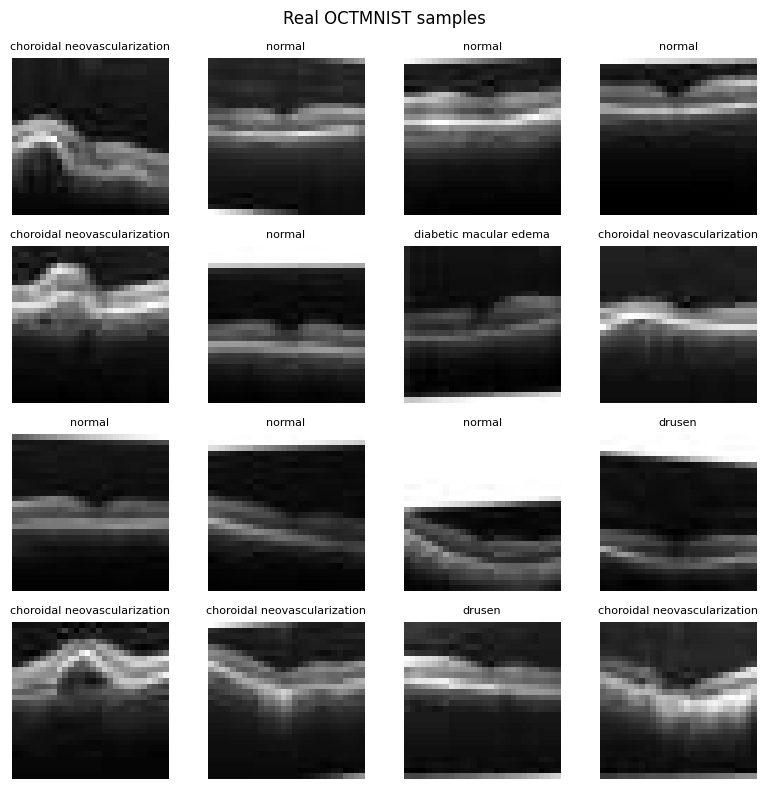

In [3]:
def show_image_grid(images, labels=None, class_names=None, n=16, title="Sample images"):
    """
    Displays the first n images in a grid. If labels and class_names are
    provided, each image is titled with its class.
    """
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(8, 2 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap="gray")
        if labels is not None and class_names is not None:
            plt.title(class_names[str(labels[i])], fontsize=8)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_image_grid(images, labels, class_names, n=16, title="Real OCTMNIST samples")

## 3. Prepare the data for DCGAN training

We normalise the images to the range **[-1, 1]** (standard for DCGANs, since
the generator uses a Tanh output), reshape them to include a channel
dimension, and wrap them in a PyTorch `DataLoader` for batched training.

In [4]:
from torch.utils.data import TensorDataset, DataLoader

def prepare_dataloader(images, batch_size=128):
    """
    Normalises images to [-1, 1], adds a channel dimension, and returns
    a DataLoader for batched training.

    Args:
        images: numpy array of shape (N, 28, 28), values 0-255
        batch_size: training batch size

    Returns:
        A PyTorch DataLoader yielding batches of shape (B, 1, 28, 28).
    """
    # Scale 0-255 -> [-1, 1] (matches the generator's Tanh output)
    imgs = images.astype(np.float32) / 127.5 - 1.0

    # Add channel dimension: (N, 28, 28) -> (N, 1, 28, 28)
    imgs = torch.from_numpy(imgs).unsqueeze(1)

    dataset = TensorDataset(imgs)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return loader


BATCH_SIZE = 128
train_loader = prepare_dataloader(images, batch_size=BATCH_SIZE)

# Sanity check on one batch
batch = next(iter(train_loader))[0]
print("Batch shape:", batch.shape)
print("Batch value range:", batch.min().item(), "to", batch.max().item())

Batch shape: torch.Size([128, 1, 28, 28])
Batch value range: -1.0 to 1.0


## 4. Build the DCGAN

A DCGAN uses convolutional layers instead of fully-connected ones:

- **Generator**: takes a noise vector and uses *transposed convolutions*
  (`ConvTranspose2d`) to progressively upsample it into a 28×28 image. Batch
  normalisation and ReLU are used between layers, with a Tanh output.
- **Discriminator**: a standard CNN that downsamples a 28×28 image through
  strided convolutions to a single real/fake score, using LeakyReLU.

This convolutional design lets the model learn spatial features (edges,
retinal layers) far more effectively than a fully-connected GAN.

In [5]:
class Generator(nn.Module):
    """
    DCGAN generator: maps a noise vector (noise_dim) to a 1x28x28 image
    using transposed convolutions to upsample. BatchNorm + ReLU between
    layers; Tanh output to match the [-1, 1] data range.
    """
    def __init__(self, noise_dim=100, feature_maps=64):
        super().__init__()
        self.noise_dim = noise_dim
        self.net = nn.Sequential(
            # Input: (noise_dim, 1, 1) -> (fm*4, 7, 7)
            nn.ConvTranspose2d(noise_dim, feature_maps * 4, kernel_size=7,
                               stride=1, padding=0, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),
            # (fm*4, 7, 7) -> (fm*2, 14, 14)
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, kernel_size=4,
                               stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),
            # (fm*2, 14, 14) -> (1, 28, 28)
            nn.ConvTranspose2d(feature_maps * 2, 1, kernel_size=4,
                               stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        # z arrives as (B, noise_dim); reshape to (B, noise_dim, 1, 1)
        z = z.view(z.size(0), self.noise_dim, 1, 1)
        return self.net(z)


class Discriminator(nn.Module):
    """
    DCGAN discriminator: a CNN that downsamples a 1x28x28 image through
    strided convolutions to a single logit (real/fake). LeakyReLU + BatchNorm;
    no sigmoid (we use BCEWithLogitsLoss).
    """
    def __init__(self, feature_maps=64):
        super().__init__()
        self.net = nn.Sequential(
            # (1, 28, 28) -> (fm, 14, 14)
            nn.Conv2d(1, feature_maps, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (fm, 14, 14) -> (fm*2, 7, 7)
            nn.Conv2d(feature_maps, feature_maps * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (fm*2, 7, 7) -> (1, 1, 1)
            nn.Conv2d(feature_maps * 2, 1, kernel_size=7, stride=1, padding=0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)  # flatten to (B, 1)

## 5. Weight initialisation

The DCGAN paper recommends initialising all weights from a Normal distribution
with mean 0 and standard deviation 0.02. This helps training stability early
on. We apply it to both the generator and discriminator.

In [6]:
def weights_init(m):
    """
    DCGAN weight initialisation (Radford et al., 2016):
    - Conv/ConvTranspose weights ~ Normal(0, 0.02)
    - BatchNorm weights ~ Normal(1, 0.02), biases = 0
    """
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


NOISE_DIM = 100

gen = Generator(noise_dim=NOISE_DIM, feature_maps=64).to(device)
disc = Discriminator(feature_maps=64).to(device)

gen.apply(weights_init)
disc.apply(weights_init)

# Quick shape check: generate one batch of fake images
z = torch.randn(8, NOISE_DIM, device=device)
fake = gen(z)
print("Generator output shape:", fake.shape)   # expect (8, 1, 28, 28)

# And check the discriminator accepts it
out = disc(fake)
print("Discriminator output shape:", out.shape)  # expect (8, 1)

Generator output shape: torch.Size([8, 1, 28, 28])
Discriminator output shape: torch.Size([8, 1])


## 6. Train the DCGAN

We train with the standard GAN objective using `BCEWithLogitsLoss` and the
Adam optimiser with the DCGAN-recommended settings (lr = 0.0002, betas =
(0.5, 0.999)). We track generator and discriminator losses, and save a fixed
batch of noise so we can visualise the same latent points evolving across
epochs.

In [8]:
def train_dcgan(gen, disc, dataloader, noise_dim=100,
                n_epochs=30, lr=2e-4, log_every=1):
    """
    Trains a DCGAN with the standard GAN objective (BCEWithLogitsLoss).
    Tracks generator/discriminator losses and stores generated images from a
    fixed noise batch each epoch so we can watch quality improve.

    Returns (g_losses, d_losses, fixed_noise_snapshots).
    """
    criterion = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

    # Fixed noise so we can visualise the same latent points across epochs
    fixed_noise = torch.randn(16, noise_dim, device=device)

    g_losses, d_losses = [], []
    snapshots = []

    for epoch in range(n_epochs):
        epoch_g, epoch_d, n_batches = 0.0, 0.0, 0

        for (real_imgs,) in dataloader:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            real_labels = torch.ones(b_size, 1, device=device)
            fake_labels = torch.zeros(b_size, 1, device=device)

            # ---- Train Discriminator ----
            z = torch.randn(b_size, noise_dim, device=device)
            fake_imgs = gen(z)

            d_real = criterion(disc(real_imgs), real_labels)
            d_fake = criterion(disc(fake_imgs.detach()), fake_labels)
            d_loss = d_real + d_fake

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # ---- Train Generator ----
            g_loss = criterion(disc(fake_imgs), real_labels)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g += g_loss.item()
            epoch_d += d_loss.item()
            n_batches += 1

        g_losses.append(epoch_g / n_batches)
        d_losses.append(epoch_d / n_batches)

        # Snapshot generated images from fixed noise
        gen.eval()
        with torch.no_grad():
            snap = gen(fixed_noise).cpu()
        gen.train()
        snapshots.append(snap)

        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | D loss: {d_losses[-1]:.4f} "
                  f"| G loss: {g_losses[-1]:.4f}")

    return g_losses, d_losses, snapshots

In [9]:
N_EPOCHS = 30

g_losses, d_losses, snapshots = train_dcgan(
    gen, disc, train_loader, noise_dim=NOISE_DIM, n_epochs=N_EPOCHS
)

print("Training complete.")

Epoch 1/30 | D loss: 0.5567 | G loss: 2.1931
Epoch 2/30 | D loss: 0.6685 | G loss: 1.7750
Epoch 3/30 | D loss: 0.7866 | G loss: 1.6911
Epoch 4/30 | D loss: 0.8410 | G loss: 1.6249
Epoch 5/30 | D loss: 0.8560 | G loss: 1.6117
Epoch 6/30 | D loss: 0.8567 | G loss: 1.6291
Epoch 7/30 | D loss: 0.8560 | G loss: 1.6369
Epoch 8/30 | D loss: 0.8582 | G loss: 1.6405
Epoch 9/30 | D loss: 0.9019 | G loss: 1.6044
Epoch 10/30 | D loss: 0.8989 | G loss: 1.5942
Epoch 11/30 | D loss: 0.9181 | G loss: 1.5879
Epoch 12/30 | D loss: 0.9267 | G loss: 1.5862
Epoch 13/30 | D loss: 0.9457 | G loss: 1.5850
Epoch 14/30 | D loss: 0.9332 | G loss: 1.5911
Epoch 15/30 | D loss: 0.9255 | G loss: 1.5830
Epoch 16/30 | D loss: 0.9274 | G loss: 1.6301
Epoch 17/30 | D loss: 0.9018 | G loss: 1.6316
Epoch 18/30 | D loss: 0.9118 | G loss: 1.6623
Epoch 19/30 | D loss: 0.8960 | G loss: 1.6820
Epoch 20/30 | D loss: 0.8627 | G loss: 1.7199
Epoch 21/30 | D loss: 0.8593 | G loss: 1.7547
Epoch 22/30 | D loss: 0.8646 | G loss: 1.75

## 7. Training results: loss curves and generated images

We plot the loss curves, then visualise the generated retinal images from the
fixed noise batch — both at the final epoch and across training, to see how
image quality evolved.

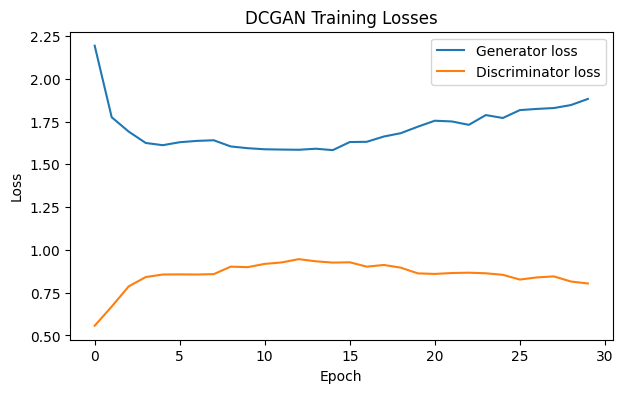

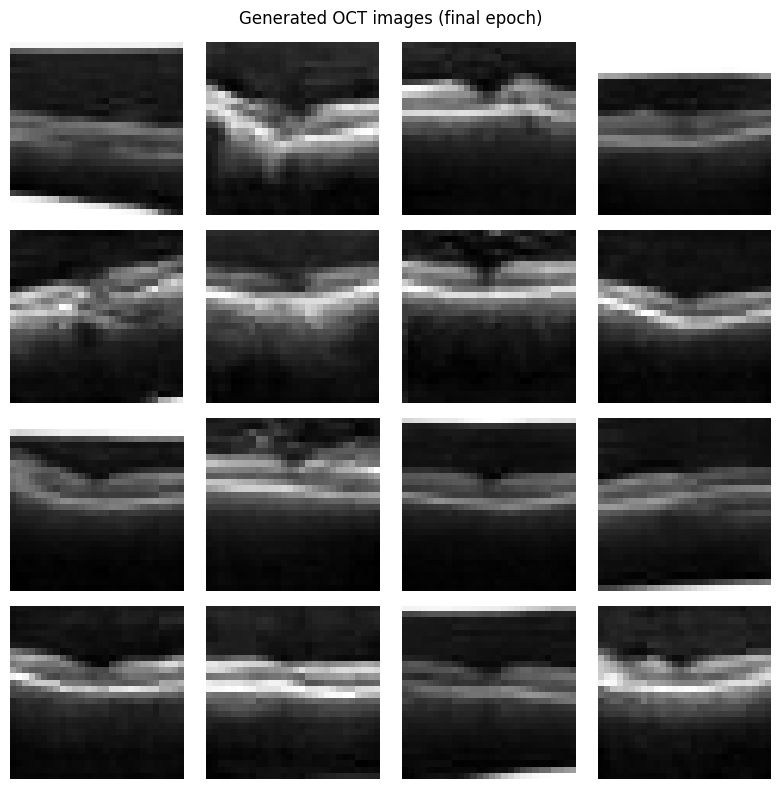

In [10]:
def plot_dcgan_losses(g_losses, d_losses, title="DCGAN Training Losses"):
    """Plots generator and discriminator loss curves per epoch."""
    plt.figure(figsize=(7, 4))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend()
    plt.show()


def show_generated_grid(snapshot, n=16, title="Generated images"):
    """
    Displays a grid of generated images from a snapshot tensor of shape
    (N, 1, 28, 28). Values are rescaled from [-1, 1] back to [0, 1].
    """
    imgs = (snapshot + 1) / 2.0  # [-1,1] -> [0,1]
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(8, 2 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(imgs[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# Loss curves
plot_dcgan_losses(g_losses, d_losses)

# Final-epoch generated images (from the fixed noise batch)
show_generated_grid(snapshots[-1], n=16, title="Generated OCT images (final epoch)")

## 8. How generated images evolved across training

Because we saved the output of a fixed noise batch at every epoch, we can show
the *same* latent points sharpening from noise into retinal structures. This
illustrates the generator progressively learning the data distribution.

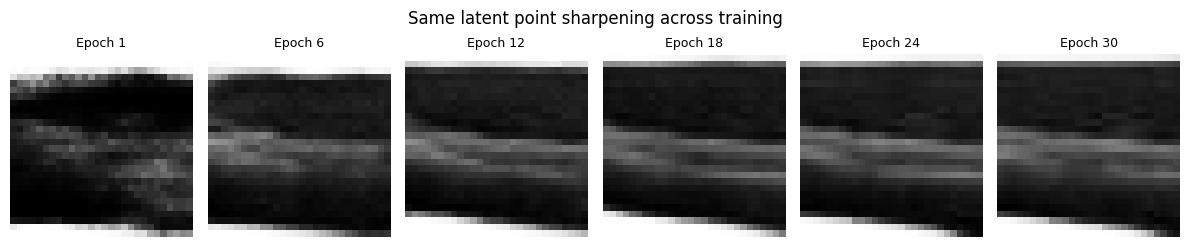

In [11]:
def show_evolution(snapshots, epochs_to_show=None, img_index=0):
    """
    Shows how a single fixed latent point's generated image evolved across
    training. Picks a few epochs and displays that image at each.

    Args:
        snapshots:       list of (16, 1, 28, 28) tensors, one per epoch
        epochs_to_show:  which epoch indices to display (default: spread of 6)
        img_index:       which of the 16 fixed images to track (0-15)
    """
    n_epochs = len(snapshots)
    if epochs_to_show is None:
        # Pick 6 evenly-spaced epochs across training
        epochs_to_show = np.linspace(0, n_epochs - 1, 6, dtype=int)

    plt.figure(figsize=(12, 2.5))
    for i, ep in enumerate(epochs_to_show):
        img = (snapshots[ep][img_index, 0] + 1) / 2.0  # [-1,1] -> [0,1]
        plt.subplot(1, len(epochs_to_show), i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Epoch {ep + 1}", fontsize=9)
        plt.axis("off")
    plt.suptitle("Same latent point sharpening across training")
    plt.tight_layout()
    plt.show()


show_evolution(snapshots, img_index=0)

## 9. Quantitative evaluation: Fréchet Inception Distance (FID)

FID measures the distance between the distributions of real and generated
images in the feature space of a pretrained InceptionV3 network. **Lower FID =
generated images are statistically closer to the real ones.**

We use the standard `pytorch-fid` implementation. Since our images are 28×28
grayscale but InceptionV3 expects 224×224 RGB, we save real and generated
images to disk (the library handles the resizing and channel conversion), then
compute FID between the two sets.

In [12]:
!pip install pytorch-fid -q

import os
from torchvision.utils import save_image

def save_images_for_fid(tensor_imgs, folder, prefix="img"):
    """
    Saves a batch of images (values in [-1, 1], shape (N, 1, 28, 28)) as PNG
    files into `folder`. Rescales to [0, 1] for saving.
    """
    os.makedirs(folder, exist_ok=True)
    imgs = (tensor_imgs + 1) / 2.0  # [-1,1] -> [0,1]
    for i in range(imgs.size(0)):
        save_image(imgs[i], os.path.join(folder, f"{prefix}_{i}.png"))


N_FID = 1000  # number of images per set to compare

# ---- Real images ----
real_subset = images[:N_FID].astype(np.float32) / 127.5 - 1.0
real_tensor = torch.from_numpy(real_subset).unsqueeze(1)  # (N,1,28,28)
save_images_for_fid(real_tensor, "fid_real", prefix="real")

# ---- Generated images ----
gen.eval()
with torch.no_grad():
    z = torch.randn(N_FID, NOISE_DIM, device=device)
    fake_tensor = gen(z).cpu()
gen.train()
save_images_for_fid(fake_tensor, "fid_fake", prefix="fake")

print(f"Saved {N_FID} real images to 'fid_real/' and {N_FID} generated images to 'fid_fake/'.")

Saved 1000 real images to 'fid_real/' and 1000 generated images to 'fid_fake/'.


In [13]:
# Compute FID between the real and generated image folders.
# pytorch-fid handles resizing to InceptionV3's expected input and
# grayscale -> RGB conversion internally.
!python -m pytorch_fid fid_real fid_fake --device cuda

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:02<00:00, 35.1MB/s]
100% 20/20 [00:05<00:00,  3.77it/s]
100% 20/20 [00:05<00:00,  3.87it/s]
FID:  33.61119420636834
